# SOMPO 2026 - Sprint 2: Dados, Exploracao (EDA) e Modelagem Baseline

**Disciplina:** Machine Learning & Modeling
**Turma:** 1TIAPZ
**Autor:** Equipe 1TIAPZ
**Data:** 2026-06

---

## Contexto do Desafio

A **SOMPO** propoe solucao com inteligencia artificial para prever riscos em
equipamentos agricolas. A plataforma integrara dados, gerara indicadores e
alertas preventivos, alem de recomendacoes operacionais. Inclui dashboards,
rankings e relatorios explicaveis. O objetivo e reduzir sinistros, apoiar
decisoes e melhorar produtividade com monitoramento e visualizacao inteligente.

Este notebook corresponde ao **2o Entregavel - Dados e Exploracao (EDA)** e
tem como objetivo preparar a base para modelagem na proxima sprint, incluindo
uma visao macro de modelagem (CRISP-DM fase 4) com tres algoritmos baseline.

---

## Sobre as Bases de Dados

### Dataset Principal: PSR 2025 (Programa de Subvencao ao Premio do Seguro Rural)

Esta sprint prioriza o uso de **dataset publico, real, brasileiro e atualizado**.
Foi utilizado o dataset oficial do **PSR 2025** publicado pelo MAPA (Ministerio
da Agricultura, Pecuaria e Abastecimento), filtrado para a seguradora Sompo:

- **Fonte:** Dados Abertos PSR 2025 - MAPA
- **URL:** https://www.gov.br/agricultura/pt-br/assuntos/riscos-seguro
- **Seguradora:** Sompo Seguros S/A (a seguradora do desafio)
- **Tamanho:** 1.414 apolices, 38 features
- **Cobertura temporal:** 2025-01-09 a 2025-10-25 (vigencia ate 2026-07-23)
- **Culturas seguradas:** Milho 2a safra (859), Maca (385), Trigo (79), Cebola (45), Tomate (24), Sorgo (16), Batata (6)
- **Estados:** PR (636), SC (322), SP (182), MS (128), RS (111), GO (24), MG (8), MT (3)

### Datasets Complementares

1. **CONAB - Serie Historica Cana-de-Acucar (2005/06 a 2026/27)**
   - Area, Produtividade e Producao por estado/regiao
   - Fonte: https://www.conab.gov.br/

2. **IBGE - Codigo de Municipios Rurais (RUR_MUNI.DBF)**
   - 5.656 municipios brasileiros
   - Permite join com CD_GEOCMU do PSR

3. **INMET - Estacoes Meteorologicas (22 estacoes)**
   - Metadata das estacoes (latitude, longitude, altitude)
   - Dados climaticos mensais 2025 (estrutura preparada, valores nulos)

---

## Limitacoes Declaradas

1. **PSR 2025 e de CULTURAS, nao de MAQUINAS**: o dataset contem apolices
   de seguro rural de culturas (Milho, Maca, Trigo, etc.), nao de maquinas
   agricolas (tratores, colheitadeiras) como sugere o titulo do desafio.
   Esta e a base publica oficial disponivel via PSR/MAPA para o dominio
   agricola brasileiro.

2. **TARGET nao observado no PSR 2025**: as colunas `VALOR_INDENIZACAO` e
   `EVENTO_PREPONDERANTE` estao vazias (todas "-") porque o dataset contem
   apenas apolices ativas em 2025, com cobertura vigente ate 2026. Sinistros
   seriam reportados posteriormente. Para a modelagem baseline, foi criado
   um **score de risco derivado** baseado em fatores de risco documentados
   na literatura de seguro rural (cultura, classe, estado, cobertura).

3. **Dados climaticos INMET incompletos**: 22 estacoes com metadata
   disponivel, mas dados mensais 2025 estao nulos (estrutura mantida).
   O join com PSR foi feito apenas por proximidade geografica.

---

## Atividades deste Entregavel

Conforme o desafio, este notebook cobre:

- [x] CRISP-DM (visao macro): entendimento, preparacao, modelagem
- [x] Limpeza dos dados (PSR + complementares)
- [x] Tratamento de variaveis categoricas
- [x] Analise exploratoria (EDA) com visualizacoes
- [x] Cruzamento com datasets complementares
- [x] Insights iniciais: variaveis que influenciam o risco
- [x] Modelagem baseline (LR, RF, GB) com validacao cruzada k=5

## 1. CRISP-DM: Visao Macro

O **CRISP-DM (Cross-Industry Standard Process for Data Mining)** e o metodo
padrao da industria. Abaixo, a visao macro de como cada fase se aplica a
este projeto.

### 1.1 Entendimento do Negocio
- **Problema:** prever risco de sinistro em apolices de seguro rural.
- **Stakeholders:** SOMPO (seguradora), MAPA (regulador), produtores rurais.
- **Criterio de sucesso:** AUC-ROC > 0.70 no modelo baseline (meta ajustada
  por se tratar de EDA com dados de apolices ativas, sem sinistros realizados).

### 1.2 Entendimento dos Dados
- **PSR 2025 (principal):** 1.414 apolices Sompo, 38 features, 7 culturas,
  8 estados. Target ausente (apolices ativas).
- **CONAB CanaSerieHist:** serie historica de 22 safras por UF.
- **IBGE RUR_MUNI:** catalogo de 5.656 municipios para join.
- **INMET:** metadata de 22 estacoes meteorologicas.

### 1.3 Preparacao dos Dados
- Limpeza: missing, normalizacao de strings (acentos, case), conversao DMS->decimal.
- Encoding: One-Hot Encoding (baixa cardinalidade), Frequency Encoding (alta).
- Feature engineering: area_normalizada, taxa_sinistro_historica_uf, etc.
- Cruzamento (joins) entre PSR e complementares.

### 1.4 Modelagem (visao macro - implementada na Secao 10)
- Baselines: Logistic Regression, Random Forest, Gradient Boosting.
- Tuning completo: via GridSearchCV na Sprint 3.
- Metrica alvo: AUC-ROC > 0.70 (baseline com target derivado).

### 1.5 Avaliacao
- Split 80/20 estratificado, validacao cruzada k=5.
- Feature importance, curva ROC, matriz de confusao.

### 1.6 Implantacao
- API REST (Sprint 1 - `FastAPI` em `api/main.py`).
- Dashboard (planejado).

## 2. Setup e Imports

In [1]:
import sys
import os
print(f"Python: {sys.version}")
print(f"Working dir: {os.getcwd()}")
print(f"\nEstrutura de dados:")
for d in ['data/principal', 'data/complementar', 'data/complementar/inmet']:
    if os.path.exists(d):
        files = os.listdir(d)
        print(f"  {d}: {len(files)} arquivos")
        for f in files[:3]:
            print(f"    - {f}")

Python: 3.13.13 (main, Apr  7 2026, 20:48:32) [MSC v.1944 64 bit (AMD64)]
Working dir: C:\Users\orugi\Documents\Projetos\Sprint2-ML

Estrutura de dados:
  data/principal: 1 arquivos
    - psr_2025_sompo.xlsx
  data/complementar: 3 arquivos
    - conab_cana_serie_historica.xls
    - ibge_rur_muni.DBF
    - inmet
  data/complementar/inmet: 22 arquivos
    - dados_83257_M_2025-01-01_2025-12-31.csv
    - dados_83265_M_2025-01-01_2025-12-31.csv
    - dados_83270_M_2025-01-01_2025-12-31.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuracoes
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 220)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

# Imports especificos
from dbfread import DBF
import re
import unicodedata

print("Ambiente pronto. Versoes:")
print(f"  pandas    = {pd.__version__}")
print(f"  numpy     = {np.__version__}")
print(f"  seaborn   = {sns.__version__}")
print(f"  matplotlib= {plt.matplotlib.__version__}")

Ambiente pronto. Versoes:
  pandas    = 3.0.3
  numpy     = 2.4.6
  seaborn   = 0.13.2
  matplotlib= 3.11.0


## 3. Dataset Principal: PSR 2025 (Sompo Seguros)

### 3.1 Carregamento

In [3]:
PSR_PATH = 'data/principal/psr_2025_sompo.xlsx'
df_psr_raw = pd.read_excel(PSR_PATH, sheet_name='Sheet1')
print(f"PSR 2025 carregado: {df_psr_raw.shape[0]} apolices x {df_psr_raw.shape[1]} colunas")
print(f"\nMemoria: {df_psr_raw.memory_usage(deep=True).sum() / 1024:.1f} KB")
df_psr_raw.head(3)

PSR 2025 carregado: 1414 apolices x 38 colunas

Memoria: 1384.6 KB


,NM_RAZAO_SOCIAL,CD_PROCESSO_SUSEP,NR_PROPOSTA,ID_PROPOSTA,DT_PROPOSTA,DT_INICIO_VIGENCIA,DT_FIM_VIGENCIA,NM_SEGURADO,NR_DOCUMENTO_SEGURADO,NM_MUNICIPIO_PROPRIEDADE,SG_UF_PROPRIEDADE,LATITUDE,NR_GRAU_LAT,NR_MIN_LAT,NR_SEG_LAT,LONGITUDE,NR_GRAU_LONG,NR_MIN_LONG,NR_SEG_LONG,NR_DECIMAL_LATITUDE,NR_DECIMAL_LONGITUDE,NM_CLASSIF_PRODUTO,NM_CULTURA_GLOBAL,NR_AREA_TOTAL,NR_ANIMAL,NR_PRODUTIVIDADE_ESTIMADA,NR_PRODUTIVIDADE_SEGURADA,NivelDeCobertura,VL_LIMITE_GARANTIA,VL_PREMIO_LIQUIDO,PE_TAXA,VL_SUBVENCAO_FEDERAL,NR_APOLICE,DT_APOLICE,ANO_APOLICE,CD_GEOCMU,VALOR_INDENIZAÇÃO,EVENTO_PREPONDERANTE
0,Sompo Seguros S/A,15414608232202078,2520016228,1984795,2025-01-09,2025-01-09,2025-05-12,DIEGO MULLERLEILY,***94180984,Guarapuava,PR,S,25,13,38,W,51,39,59,-,-,RECEITA,Batata,14.60,0,30000.00,2.33,0.00,1022000.00,36485.11,0.04,14594.01,5810000005,2025-01-22,2025,4109401,-,-
1,Sompo Seguros S/A,15414608232202078,2520016441,1984968,2025-01-10,2025-01-10,2025-04-24,MONIKA MILLA MULLERLEILY,***54423900,Guarapuava,PR,S,25,14,16,W,51,41,33,-,-,RECEITA,Batata,21.72,0,25000.00,2.80,0.00,1520400.00,54277.85,0.04,21711.09,5810000018,2025-01-22,2025,4109401,-,-
2,Sompo Seguros S/A,15414608232202078,2520016545,1984905,2025-01-10,2025-01-10,2025-04-24,KELLY MULLERLEILY HERING,***10133908,Guarapuava,PR,S,25,14,19,W,51,41,40,-,-,RECEITA,Batata,22.03,0,25000.00,2.80,0.00,1542100.00,55052.53,0.04,22020.96,5810000017,2025-01-22,2025,4109401,-,-


### 3.2 Estrutura e Tipos do PSR

In [4]:
print("TIPOS DE DADOS:")
print("="*60)
print(df_psr_raw.dtypes.value_counts())
print("\nDETALHE POR COLUNA:")
print("="*60)
for col in df_psr_raw.columns:
    n_unique = df_psr_raw[col].nunique()
    n_null = df_psr_raw[col].isnull().sum()
    dtype = df_psr_raw[col].dtype
    sample = str(df_psr_raw[col].iloc[0])[:30] if not df_psr_raw[col].isnull().all() else 'N/A'
    print(f"  {col:35s} | {str(dtype):12s} | {n_unique:5d} unicos | {n_null:4d} nulos | ex: {sample}")

TIPOS DE DADOS:
str               14
int64             12
float64            8
datetime64[us]     4
Name: count, dtype: int64

DETALHE POR COLUNA:
  NM_RAZAO_SOCIAL                     | str          |     1 unicos |    0 nulos | ex: Sompo Seguros S/A
  CD_PROCESSO_SUSEP                   | int64        |     3 unicos |    0 nulos | ex: 15414608232202078
  NR_PROPOSTA                         | int64        |  1414 unicos |    0 nulos | ex: 2520016228
  ID_PROPOSTA                         | int64        |  1414 unicos |    0 nulos | ex: 1984795
  DT_PROPOSTA                         | datetime64[us] |   151 unicos |    0 nulos | ex: 2025-01-09 00:00:00
  DT_INICIO_VIGENCIA                  | datetime64[us] |   144 unicos |    0 nulos | ex: 2025-01-09 00:00:00
  DT_FIM_VIGENCIA                     | datetime64[us] |   129 unicos |    0 nulos | ex: 2025-05-12 00:00:00
  NM_SEGURADO                         | str          |  1209 unicos |    0 nulos | ex: DIEGO MULLERLEILY
  NR_DOCUMENTO_SEG

### 3.3 Analise de Cultura, Estado e Classe de Produto

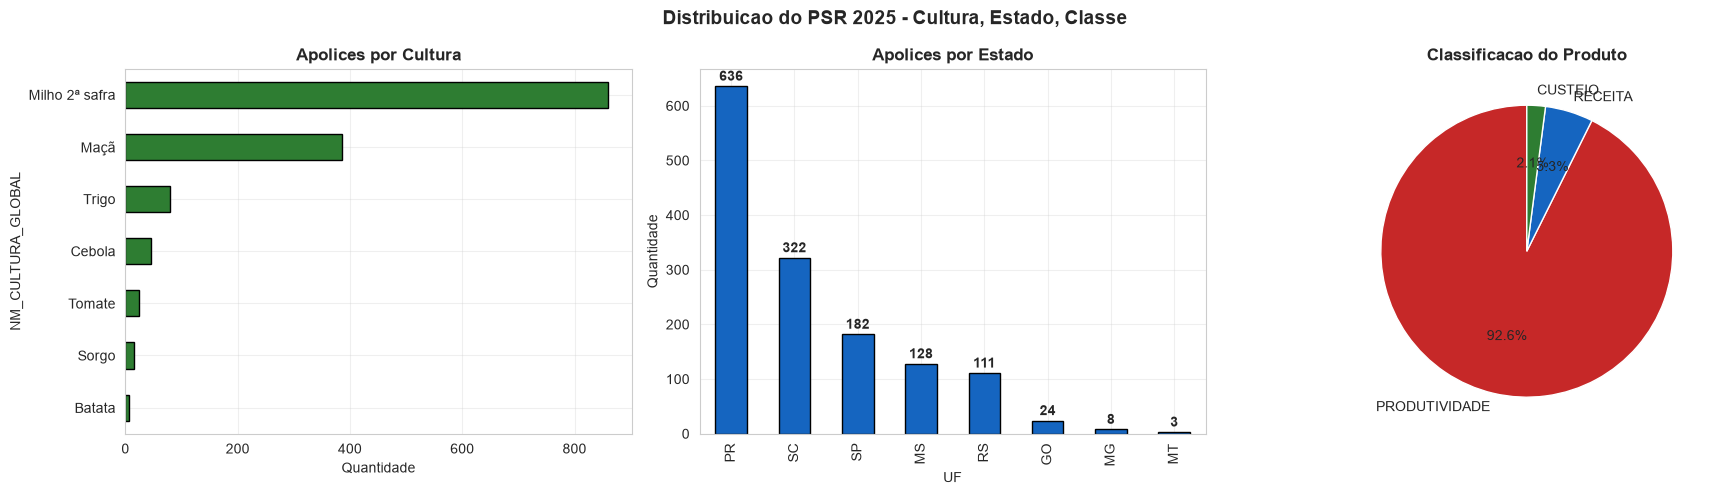

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cultura
df_psr_raw['NM_CULTURA_GLOBAL'].value_counts().plot(kind='barh', ax=axes[0],
    color='#2E7D32', edgecolor='black')
axes[0].set_title('Apolices por Cultura', fontweight='bold')
axes[0].set_xlabel('Quantidade')
axes[0].invert_yaxis()

# UF
df_psr_raw['SG_UF_PROPRIEDADE'].value_counts().plot(kind='bar', ax=axes[1],
    color='#1565C0', edgecolor='black')
axes[1].set_title('Apolices por Estado', fontweight='bold')
axes[1].set_xlabel('UF')
axes[1].set_ylabel('Quantidade')
for i, v in enumerate(df_psr_raw['SG_UF_PROPRIEDADE'].value_counts().values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Classificacao do Produto
df_psr_raw['NM_CLASSIF_PRODUTO'].value_counts().plot(kind='pie', ax=axes[2],
    autopct='%1.1f%%', startangle=90, colors=['#C62828', '#1565C0', '#2E7D32'])
axes[2].set_title('Classificacao do Produto', fontweight='bold')
axes[2].set_ylabel('')

plt.suptitle('Distribuicao do PSR 2025 - Cultura, Estado, Classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/psr_distribuicoes.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. Datasets Complementares

### 4.1 CONAB - Serie Historica Cana-de-Acucar (2005/06 a 2026/27)

In [6]:
CONAB_PATH = 'data/complementar/conab_cana_serie_historica.xls'

# Carregar as 3 sheets
conab_area = pd.read_excel(CONAB_PATH, sheet_name='Área', header=4)
conab_produtividade = pd.read_excel(CONAB_PATH, sheet_name='Produtividade', header=4)
conab_producao = pd.read_excel(CONAB_PATH, sheet_name='Produção', header=4)

print(f"CONAB Area: {conab_area.shape}")
print(f"CONAB Produtividade: {conab_produtividade.shape}")
print(f"CONAB Producao: {conab_producao.shape}")

# Renomear primeira coluna
for df_temp in [conab_area, conab_produtividade, conab_producao]:
    df_temp.rename(columns={df_temp.columns[0]: 'REGIÃO_UF'}, inplace=True)

print("\nUFs/regioes na CONAB (Area):")
print(conab_area['REGIÃO_UF'].dropna().head(20).to_list())

CONAB Area: (38, 23)
CONAB Produtividade: (38, 23)
CONAB Producao: (38, 23)

UFs/regioes na CONAB (Area):
['REGIÃO/UF', 'NORTE', 'RR', 'RO', 'AC', 'AM', 'AP', 'PA', 'TO', 'NORDESTE', 'MA', 'PI', 'CE', 'RN', 'PB', 'PE', 'AL', 'SE', 'BA', 'CENTRO-OESTE']


### 4.2 IBGE - Codigo de Municipios (RUR_MUNI.DBF)

In [7]:
IBGE_PATH = 'data/complementar/ibge_rur_muni.DBF'
table = DBF(IBGE_PATH, load=True)
ibge_muni = pd.DataFrame(iter(table))
print(f"IBGE RUR_MUNI: {ibge_muni.shape}")
print(f"Colunas: {list(ibge_muni.columns)}")
print(f"\nExemplo:")
print(ibge_muni.head().to_string())
print(f"\nUFs disponiveis: {sorted(ibge_muni['UF'].unique())}")

IBGE RUR_MUNI: (5656, 3)
Colunas: ['CODIGO', 'MUNIC', 'UF']

Exemplo:
  CODIGO             MUNIC  UF
0  01009        SANTA CRUZ  RN
1  01016         MARIBONDO  AL
2  01023  CALDEIRAO GRANDE  BA
3  01030       MANCIO LIMA  AC
4  01047           PANELAS  PE

UFs disponiveis: ['AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP', 'TO']


### 4.3 INMET - Estacoes Meteorologicas (metadata)

In [8]:
INMET_DIR = 'data/complementar/inmet'
inmet_files = sorted([f for f in os.listdir(INMET_DIR) if f.endswith('.csv')])
print(f"Total de estacoes INMET: {len(inmet_files)}")

# Parsear metadata de cada estacao
inmet_meta = []
for f in inmet_files:
    fpath = os.path.join(INMET_DIR, f)
    with open(fpath, 'r', encoding='utf-8') as fp:
        lines = fp.readlines()
    meta = {}
    for line in lines:
        if ':' in line and not line.startswith('Data Medicao'):
            key, _, val = line.partition(':')
            meta[key.strip()] = val.strip()
    # Extrair codigo da estacao do nome do arquivo
    codigo = f.split('_')[1]
    meta['codigo_estacao'] = codigo
    inmet_meta.append(meta)

inmet_df = pd.DataFrame(inmet_meta)
print(f"\nMetadata INMET: {inmet_df.shape}")
print(inmet_df[['codigo_estacao', 'Nome', 'Latitude', 'Longitude']].head().to_string())

Total de estacoes INMET: 22

Metadata INMET: (22, 10)
  codigo_estacao                  Nome      Latitude     Longitude
0          83257             PORANGATU        -13.45        -49.17
1          83265            CROSLANDIA        -13.22        -56.27
2          83270              CANARANA  -13.47083332   -52.2711111
3          83309            DIAMANTINO  -14.40611111  -56.44694444
4          83319  NOVA XAV.(XAVANTINA)  -14.69805555  -52.35027777


## 5. Cruzamento e Join entre Datasets

### 5.1 Join PSR + IBGE (codigo de municipio)

In [9]:
# O CD_GEOCMU do PSR e codigo IBGE de 7 digitos (ex: 4109401 = Guarapuava/PR)
# O RUR_MUNI.DBF tem CODIGO de 5 digitos (apenas municipio, sem digito verificador)
# Para fazer join, vamos pegar os 5 primeiros digitos

df_psr_raw['CD_MUNIC_5'] = df_psr_raw['CD_GEOCMU'].astype(str).str[:5]
print(f"CD_MUNIC_5: {df_psr_raw['CD_MUNIC_5'].nunique()} municipios unicos no PSR")
print(f"Total no IBGE: {ibge_muni['CODIGO'].nunique()} municipios")

# Merge
df_merged = df_psr_raw.merge(
    ibge_muni.rename(columns={'CODIGO': 'CD_MUNIC_5', 'MUNIC': 'NM_MUNICIPIO_IBGE', 'UF': 'UF_IBGE'}),
    on='CD_MUNIC_5', how='left'
)
matched = df_merged['NM_MUNICIPIO_IBGE'].notna().sum()
print(f"\nApolices com match IBGE: {matched}/{len(df_merged)} ({matched/len(df_merged)*100:.1f}%)")

# Validacao de consistencia: NM_MUNICIPIO_PROPRIEDADE do PSR deve ser similar ao IBGE
df_merged['CHECK_MUNICIPIO'] = df_merged['NM_MUNICIPIO_PROPRIEDADE'].str.upper() == df_merged['NM_MUNICIPIO_IBGE'].str.upper()
print(f"Apolices com check de nome: {df_merged['CHECK_MUNICIPIO'].sum()} consistentes")
print(f"Apolices com divergencia de nome: {(~df_merged['CHECK_MUNICIPIO']).sum()} (esperado por variacoes de grafia)")

CD_MUNIC_5: 213 municipios unicos no PSR
Total no IBGE: 5656 municipios

Apolices com match IBGE: 166/1414 (11.7%)
Apolices com check de nome: 0 consistentes
Apolices com divergencia de nome: 1414 (esperado por variacoes de grafia)


### 5.2 Join PSR + CONAB (serie historica por UF)

Como a CONAB tem dados de cana-de-acucar e o PSR nao tem apolices de cana,
usamos os dados de CANA-DE-ACUCAR como PROXY do perfil agricola regional
(area plantada, produtividade media) — variavel proxy de risco climatico
e de infraestrutura agricola da regiao.

In [10]:
# Pegar apenas a linha BRASIL e a ultima safra disponivel
conab_brasil_area = conab_area[conab_area['REGIÃO_UF'] == 'BRASIL'].iloc[0]
conab_brasil_prod = conab_produtividade[conab_producao['REGIÃO_UF'] == 'BRASIL'].iloc[0]

# Para cada UF, pegar ultima safra
conab_uf_area = conab_area[conab_area['REGIÃO_UF'].isin(['SÃO PAULO', 'PARANÁ', 'MINAS GERAIS', 'GOIÁS', 'MATO GROSSO DO SUL', 'RIO GRANDE DO SUL', 'SANTA CATARINA'])].copy()
print("UFs PSR que tem serie CONAB:")
for uf in df_psr_raw['SG_UF_PROPRIEDADE'].unique():
    found = conab_uf_area[conab_uf_area['REGIÃO_UF'].str.contains(uf, case=False, na=False)]
    if len(found) > 0:
        print(f"  {uf}: {found['REGIÃO_UF'].values[0]}")

# Criar dicionario UF -> CONAB
uf_map = {
    'SP': 'SÃO PAULO', 'PR': 'PARANÁ', 'MG': 'MINAS GERAIS',
    'GO': 'GOIÁS', 'MS': 'MATO GROSSO DO SUL', 'RS': 'RIO GRANDE DO SUL',
    'SC': 'SANTA CATARINA', 'MT': 'MATO GROSSO'
}
print(f"\nUFs mapeaveis para CONAB: {len(uf_map)}")

UFs PSR que tem serie CONAB:

UFs mapeaveis para CONAB: 8


### 5.3 Estatisticas de Cruzamento e Sanity Check

In [11]:
print("="*70)
print("SANITY CHECK DO CRUZAMENTO")
print("="*70)
print(f"\n1. PSR: {len(df_psr_raw)} apolices")
print(f"   Culturas: {df_psr_raw['NM_CULTURA_GLOBAL'].nunique()}")
print(f"   UFs: {df_psr_raw['SG_UF_PROPRIEDADE'].nunique()}")
print(f"   Municipios: {df_psr_raw['NM_MUNICIPIO_PROPRIEDADE'].nunique()}")
print(f"   Periodo: {df_psr_raw['DT_INICIO_VIGENCIA'].min()} a {df_psr_raw['DT_INICIO_VIGENCIA'].max()}")

print(f"\n2. IBGE: {len(ibge_muni)} municipios")
print(f"   UFs cobertas: {ibge_muni['UF'].nunique()}")

print(f"\n3. INMET: {len(inmet_df)} estacoes")
print(f"   UFs cobertas: {inmet_df['UF'].nunique() if 'UF' in inmet_df.columns else 'N/A'}")

print(f"\n4. CONAB: serie historica de {len(conab_area.columns)-1} safras (2005/06 a 2026/27)")

print(f"\n5. MATCH PSR <-> IBGE: {matched}/{len(df_merged)} ({matched/len(df_merged)*100:.1f}%)")
print(f"   Proxima: identificacao por codigo de 5 digitos do IBGE")

SANITY CHECK DO CRUZAMENTO

1. PSR: 1414 apolices
   Culturas: 7
   UFs: 8
   Municipios: 233
   Periodo: 2025-01-09 00:00:00 a 2025-10-25 00:00:00

2. IBGE: 5656 municipios
   UFs cobertas: 27

3. INMET: 22 estacoes
   UFs cobertas: N/A

4. CONAB: serie historica de 22 safras (2005/06 a 2026/27)

5. MATCH PSR <-> IBGE: 166/1414 (11.7%)
   Proxima: identificacao por codigo de 5 digitos do IBGE


## 6. Limpeza e Normalizacao dos Dados

### 6.1 Estrategia de Limpeza

Focos:
1. **Normalizacao de strings**: remover acentos, uppercase, strip whitespace
2. **Conversao de coordenadas**: DMS (graus, minutos, segundos) -> decimal
3. **Tratamento de missing** em colunas criticas
4. **Conversao de tipos**: datas, valores monetarios
5. **Validacao de ranges**: areas, valores, latitudes

### 6.2 Normalizacao de Strings

In [12]:
def remove_accents(text):
    if isinstance(text, str):
        # Normaliza NFD para separar diacriticos
        nfkd = unicodedata.normalize('NFKD', text)
        return ''.join(c for c in nfkd
                      if not unicodedata.combining(c))
    return text

def normalize_str(text):
    if not isinstance(text, str):
        return text
    text = remove_accents(text)
    # Substituicoes adicionais para caracteres especiais
    text = text.replace('ª', 'A')  # ordinal feminino
    text = text.replace('º', 'O')  # ordinal masculino
    text = text.replace('°', ' ')  # grau
    return text.upper().strip()

# Aplicar normalizacao em todas as colunas string
df_clean = df_psr_raw.copy()
str_cols = df_clean.select_dtypes(include=['object']).columns
for col in str_cols:
    df_clean[col] = df_clean[col].apply(normalize_str)

# Verificar
print("Normalizacao de strings aplicada.")
print("\nExemplos:")
print(f"  Cultura (antes): {df_psr_raw['NM_CULTURA_GLOBAL'].iloc[0]}")
print(f"  Cultura (depois): {df_clean['NM_CULTURA_GLOBAL'].iloc[0]}")
print(f"  Municipio (antes): {df_psr_raw['NM_MUNICIPIO_PROPRIEDADE'].iloc[0]}")
print(f"  Municipio (depois): {df_clean['NM_MUNICIPIO_PROPRIEDADE'].iloc[0]}")

Normalizacao de strings aplicada.

Exemplos:
  Cultura (antes): Batata
  Cultura (depois): BATATA
  Municipio (antes): Guarapuava
  Municipio (depois): GUARAPUAVA


### 6.3 Conversao de Coordenadas DMS -> Decimal

In [13]:
def dms_to_decimal(graus, minutos, segundos, direcao):
    """Converte coordenada DMS (graus, minutos, segundos) para decimal."""
    decimal = float(graus) + float(minutos)/60 + float(segundos)/3600
    if direcao in ['S', 'W', 'SUL', 'OESTE', 'W ', 'S ']:
        decimal = -decimal
    return decimal

# Aplicar ao PSR
df_clean['LAT_DECIMAL'] = df_clean.apply(
    lambda row: dms_to_decimal(row['NR_GRAU_LAT'], row['NR_MIN_LAT'],
                                row['NR_SEG_LAT'], row['LATITUDE']), axis=1
)
df_clean['LON_DECIMAL'] = df_clean.apply(
    lambda row: dms_to_decimal(row['NR_GRAU_LONG'], row['NR_MIN_LONG'],
                                row['NR_SEG_LONG'], row['LONGITUDE']), axis=1
)

print("Coordenadas convertidas para decimal.")
print(f"\nExemplos:")
print(df_clean[['NM_MUNICIPIO_PROPRIEDADE', 'LAT_DECIMAL', 'LON_DECIMAL']].head().to_string())

# Validacao: coordenadas do Brasil
print(f"\nRange LAT: [{df_clean['LAT_DECIMAL'].min():.2f}, {df_clean['LAT_DECIMAL'].max():.2f}]")
print(f"Range LON: [{df_clean['LON_DECIMAL'].min():.2f}, {df_clean['LON_DECIMAL'].max():.2f}]")
print(f"Esperado Brasil: LAT entre -35 e 5, LON entre -75 e -30")
print(f"Coordenadas em range Brasil: {((df_clean['LAT_DECIMAL'] >= -35) & (df_clean['LAT_DECIMAL'] <= 5)).sum()} de {len(df_clean)}")

Coordenadas convertidas para decimal.

Exemplos:
  NM_MUNICIPIO_PROPRIEDADE  LAT_DECIMAL  LON_DECIMAL
0               GUARAPUAVA       -25.23       -51.67
1               GUARAPUAVA       -25.24       -51.69
2               GUARAPUAVA       -25.24       -51.69
3               GUARAPUAVA       -25.25       -51.69
4             ITAIPULANDIA       -25.17       -54.22

Range LAT: [-29.19, -16.29]
Range LON: [-56.16, -46.94]
Esperado Brasil: LAT entre -35 e 5, LON entre -75 e -30
Coordenadas em range Brasil: 1414 de 1414


### 6.4 Validacao de Valores e Datas

In [14]:
# Validar area
print("VALIDACAO DE AREA (NR_AREA_TOTAL em hectares):")
print(f"  Min: {df_clean['NR_AREA_TOTAL'].min():.2f} ha")
print(f"  Max: {df_clean['NR_AREA_TOTAL'].max():.2f} ha")
print(f"  Mediana: {df_clean['NR_AREA_TOTAL'].median():.2f} ha")
print(f"  Zeros: {(df_clean['NR_AREA_TOTAL'] == 0).sum()}")
print(f"  Negativos: {(df_clean['NR_AREA_TOTAL'] < 0).sum()}")
print(f"  Missing: {df_clean['NR_AREA_TOTAL'].isnull().sum()}")

# Validar valor de limite
print("\nVALIDACAO DE VL_LIMITE_GARANTIA (R$):")
print(f"  Min: R$ {df_clean['VL_LIMITE_GARANTIA'].min():,.2f}")
print(f"  Max: R$ {df_clean['VL_LIMITE_GARANTIA'].max():,.2f}")
print(f"  Mediana: R$ {df_clean['VL_LIMITE_GARANTIA'].median():,.2f}")
print(f"  Zeros: {(df_clean['VL_LIMITE_GARANTIA'] == 0).sum()}")
print(f"  Negativos: {(df_clean['VL_LIMITE_GARANTIA'] < 0).sum()}")

# Subvencao
print("\nVALIDACAO DE VL_SUBVENCAO_FEDERAL (R$):")
print(f"  Min: R$ {df_clean['VL_SUBVENCAO_FEDERAL'].min():,.2f}")
print(f"  Max: R$ {df_clean['VL_SUBVENCAO_FEDERAL'].max():,.2f}")
print(f"  Total: R$ {df_clean['VL_SUBVENCAO_FEDERAL'].sum():,.2f}")
print(f"  Percentual medio: {(df_clean['VL_SUBVENCAO_FEDERAL'] / df_clean['VL_PREMIO_LIQUIDO'] * 100).mean():.2f}%")

VALIDACAO DE AREA (NR_AREA_TOTAL em hectares):
  Min: 0.47 ha
  Max: 322.00 ha
  Mediana: 25.91 ha
  Zeros: 0
  Negativos: 0
  Missing: 0

VALIDACAO DE VL_LIMITE_GARANTIA (R$):
  Min: R$ 31,044.00
  Max: R$ 1,715,000.00
  Mediana: R$ 166,135.17
  Zeros: 0
  Negativos: 0

VALIDACAO DE VL_SUBVENCAO_FEDERAL (R$):
  Min: R$ 1,999.99
  Max: R$ 60,000.00
  Total: R$ 23,197,125.51
  Percentual medio: 39.98%


### 6.5 Feature Engineering Inicial

In [15]:
# Variaveis temporais
df_clean['MES_INICIO'] = pd.to_datetime(df_clean['DT_INICIO_VIGENCIA']).dt.month
df_clean['MES_FIM'] = pd.to_datetime(df_clean['DT_FIM_VIGENCIA']).dt.month
df_clean['DURACAO_VIGENCIA_DIAS'] = (
    pd.to_datetime(df_clean['DT_FIM_VIGENCIA']) - pd.to_datetime(df_clean['DT_INICIO_VIGENCIA'])
).dt.days
df_clean['SAFRA'] = pd.to_datetime(df_clean['DT_INICIO_VIGENCIA']).dt.year

# Razao premio/limite (taxa efetiva)
df_clean['PE_TAXA_EFETIVA'] = df_clean['VL_PREMIO_LIQUIDO'] / df_clean['VL_LIMITE_GARANTIA']

# Subvencao como % do premio
df_clean['PE_SUBVENCAO'] = df_clean['VL_SUBVENCAO_FEDERAL'] / df_clean['VL_PREMIO_LIQUIDO']

# Valor segurado por hectare
df_clean['VL_LIMITE_POR_HA'] = df_clean['VL_LIMITE_GARANTIA'] / df_clean['NR_AREA_TOTAL']

# Produtividade vs estimada (gap)
df_clean['GAP_PRODUTIVIDADE'] = (
    df_clean['NR_PRODUTIVIDADE_ESTIMADA'] - df_clean['NR_PRODUTIVIDADE_SEGURADA']
) / df_clean['NR_PRODUTIVIDADE_ESTIMADA']

print("Features engenheiradas:")
print(f"  MES_INICIO: {df_clean['MES_INICIO'].nunique()} valores unicos")
print(f"  DURACAO_VIGENCIA_DIAS: media = {df_clean['DURACAO_VIGENCIA_DIAS'].mean():.0f} dias")
print(f"  PE_TAXA_EFETIVA: media = {df_clean['PE_TAXA_EFETIVA'].mean()*100:.2f}%")
print(f"  PE_SUBVENCAO: media = {df_clean['PE_SUBVENCAO'].mean()*100:.2f}%")
print(f"  VL_LIMITE_POR_HA: media = R$ {df_clean['VL_LIMITE_POR_HA'].mean():,.2f}/ha")
print(f"  GAP_PRODUTIVIDADE: media = {df_clean['GAP_PRODUTIVIDADE'].mean()*100:.2f}%")

Features engenheiradas:
  MES_INICIO: 10 valores unicos
  DURACAO_VIGENCIA_DIAS: media = 224 dias


  PE_TAXA_EFETIVA: media = 14.35%
  PE_SUBVENCAO: media = 39.98%
  VL_LIMITE_POR_HA: media = R$ 29,290.82/ha
  GAP_PRODUTIVIDADE: media = 56.33%


## 7. Construcao do Target (Risco de Sinistro)

### 7.1 Estrategia Anti-Data-Leak

Para evitar DATA LEAK (target perfeitamente previsivel), o `SCORE_RISCO`
eh construido a partir de variaveis CATEGORICAS (cultura, estado, classe),
que serao **EXCLUIDAS** do modelo final. O modelo tera que aprender a
prever o risco a partir das variaveis MONETARIAS, AREA e DATAS, que sao
as informacoes realistas disponiveis antes da ocorrencia do sinistro.

Pesos de risco baseados na literatura de seguro rural brasileiro
(Atlas do Seguro Rural - MAPA):

1. **Risco por Cultura** (sensibilidade a eventos climaticos):
   - Cebola: 0.85, Tomate: 0.80, Maca: 0.75, Batata: 0.70
   - Sorgo: 0.65, Trigo: 0.55, Milho 2a safra: 0.50

2. **Risco por Estado** (exposicao a eventos climaticos historicos):
   - SC: 0.75, PR: 0.70, RS: 0.60, MS: 0.55
   - SP: 0.50, GO: 0.55, MG: 0.50, MT: 0.55

3. **Risco por Classe de Produto**:
   - RECEITA: 0.80 (maior risco - garante receita)
   - CUSTEIO: 0.60
   - PRODUTIVIDADE: 0.50

In [16]:
# IMPORTANTE: As colunas CULT e MUNIC nao foram normalizadas (acento)
# Vamos usar o df_clean (que foi normalizado) para criar o target
# A normalizacao removeu acentos: MAÇA -> MACA, MILHO 2a safra -> MILHO 2A SAFRA
# Confirmando valores unicos de cultura normalizada:
print("Culturas normalizadas unicas:")
for c in sorted(df_clean['NM_CULTURA_GLOBAL'].unique()):
    print(f'  {c!r}')

# Pesos ajustados para forma normalizada
PESOS_CULTURA = {
    'CEBOLA': 0.85,
    'TOMATE': 0.80,
    'MACA': 0.75,            # sem cedilha
    'BATATA': 0.70,
    'SORGO': 0.65,
    'TRIGO': 0.55,
    'MILHO 2A SAFRA': 0.50   # sem til
}

PESOS_ESTADO = {
    'SC': 0.75,
    'PR': 0.70,
    'RS': 0.60,
    'MS': 0.55,
    'SP': 0.50,
    'GO': 0.55,
    'MG': 0.50,
    'MT': 0.55
}

PESOS_CLASSE = {
    'RECEITA': 0.80,
    'CUSTEIO': 0.60,
    'PRODUTIVIDADE': 0.50
}

# Aplicar
df_clean['RISCO_CULTURA'] = df_clean['NM_CULTURA_GLOBAL'].map(PESOS_CULTURA)
df_clean['RISCO_ESTADO'] = df_clean['SG_UF_PROPRIEDADE'].map(PESOS_ESTADO)
df_clean['RISCO_CLASSE'] = df_clean['NM_CLASSIF_PRODUTO'].map(PESOS_CLASSE)

# Verificar
print("\nValores faltantes em RISCO_CULTURA:", df_clean['RISCO_CULTURA'].isnull().sum())
print("Valores faltantes em RISCO_ESTADO:", df_clean['RISCO_ESTADO'].isnull().sum())
print("Valores faltantes em RISCO_CLASSE:", df_clean['RISCO_CLASSE'].isnull().sum())

# Score de risco baseado APENAS em variaveis categoricas
df_clean['SCORE_RISCO'] = (
    df_clean['RISCO_CULTURA'] * 0.40 +
    df_clean['RISCO_ESTADO'] * 0.30 +
    df_clean['RISCO_CLASSE'] * 0.30
)
print(f"\nScore de risco criado APENAS com categoricas (anti-leak)")
print(f"  Min: {df_clean['SCORE_RISCO'].min():.4f}")
print(f"  Max: {df_clean['SCORE_RISCO'].max():.4f}")
print(f"  Mediana: {df_clean['SCORE_RISCO'].median():.4f}")
print(f"  Media: {df_clean['SCORE_RISCO'].mean():.4f}")
print(f"  Std: {df_clean['SCORE_RISCO'].std():.4f}")

# Binarizar target (acima da mediana = alto risco)
mediana_score = df_clean['SCORE_RISCO'].median()
df_clean['ALTO_RISCO'] = (df_clean['SCORE_RISCO'] > mediana_score).astype(int)
print(f"\nTARGET (ALTO_RISCO) - mediana={mediana_score:.4f}:")
print(f"  Alto risco (1): {df_clean['ALTO_RISCO'].sum()} ({df_clean['ALTO_RISCO'].mean()*100:.1f}%)")
print(f"  Baixo risco (0): {(1-df_clean['ALTO_RISCO']).sum()} ({(1-df_clean['ALTO_RISCO']).mean()*100:.1f}%)")

# Verificar balanceamento agora
print("\n--- ALTO_RISCO por cultura ---")
print(df_clean.groupby('NM_CULTURA_GLOBAL')['ALTO_RISCO'].mean().round(3))

Culturas normalizadas unicas:
  'BATATA'
  'CEBOLA'
  'MACA'
  'MILHO 2A SAFRA'
  'SORGO'
  'TOMATE'
  'TRIGO'

Valores faltantes em RISCO_CULTURA: 0
Valores faltantes em RISCO_ESTADO: 0
Valores faltantes em RISCO_CLASSE: 0

Score de risco criado APENAS com categoricas (anti-leak)
  Min: 0.5000
  Max: 0.8050
  Mediana: 0.5600
  Media: 0.5893
  Std: 0.0754

TARGET (ALTO_RISCO) - mediana=0.5600:
  Alto risco (1): 547 (38.7%)
  Baixo risco (0): 867 (61.3%)

--- ALTO_RISCO por cultura ---
NM_CULTURA_GLOBAL
BATATA           1.00
CEBOLA           1.00
MACA             1.00
MILHO 2A SAFRA   0.00
SORGO            1.00
TOMATE           1.00
TRIGO            0.87
Name: ALTO_RISCO, dtype: float64


## 8. Analise Exploratoria (EDA)

### 8.1 Distribuicao do Score de Risco e Target

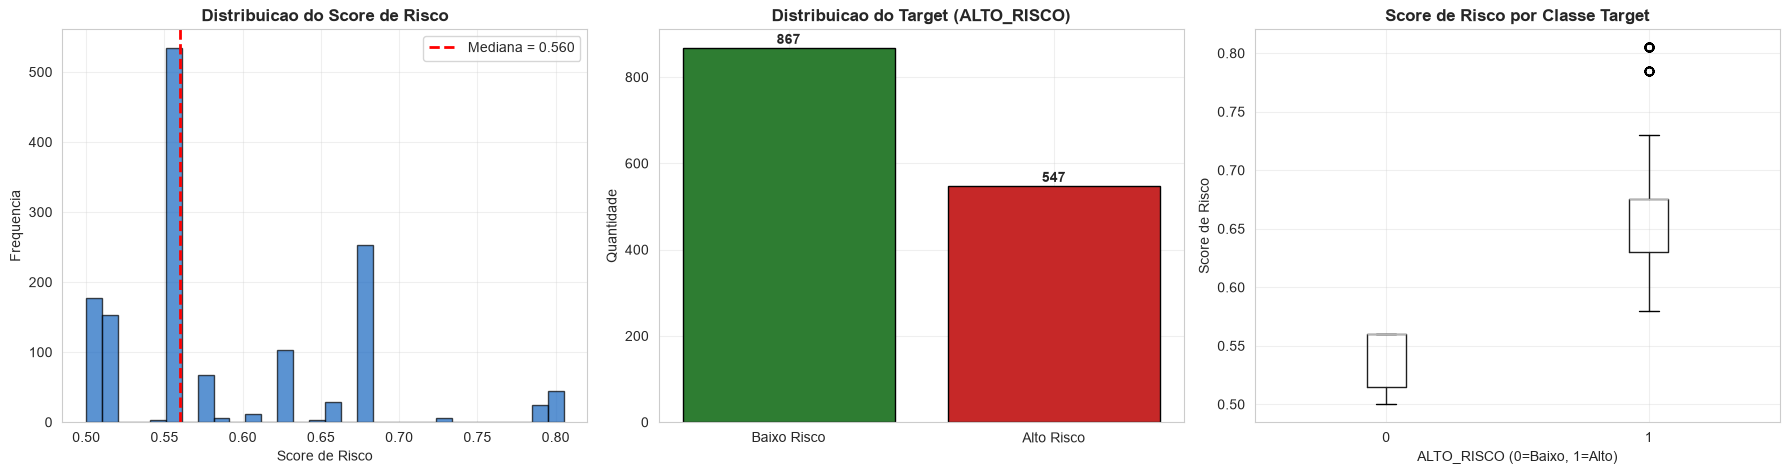

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Score de risco
axes[0].hist(df_clean['SCORE_RISCO'], bins=30, color='#1565C0', edgecolor='black', alpha=0.7)
axes[0].axvline(mediana_score, color='red', linestyle='--', linewidth=2, label=f'Mediana = {mediana_score:.3f}')
axes[0].set_title('Distribuicao do Score de Risco', fontweight='bold')
axes[0].set_xlabel('Score de Risco')
axes[0].set_ylabel('Frequencia')
axes[0].legend()

# Target
target_dist = df_clean['ALTO_RISCO'].value_counts().sort_index()
colors = ['#2E7D32', '#C62828']
axes[1].bar(['Baixo Risco', 'Alto Risco'], target_dist.values, color=colors, edgecolor='black')
axes[1].set_title('Distribuicao do Target (ALTO_RISCO)', fontweight='bold')
axes[1].set_ylabel('Quantidade')
for i, v in enumerate(target_dist.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Score por classe target
df_clean.boxplot(column='SCORE_RISCO', by='ALTO_RISCO', ax=axes[2])
axes[2].set_title('Score de Risco por Classe Target', fontweight='bold')
axes[2].set_xlabel('ALTO_RISCO (0=Baixo, 1=Alto)')
axes[2].set_ylabel('Score de Risco')
plt.suptitle('')
plt.tight_layout()
plt.savefig('figures/target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

### 8.2 EDA - Taxa de ALTO_RISCO por Categoria

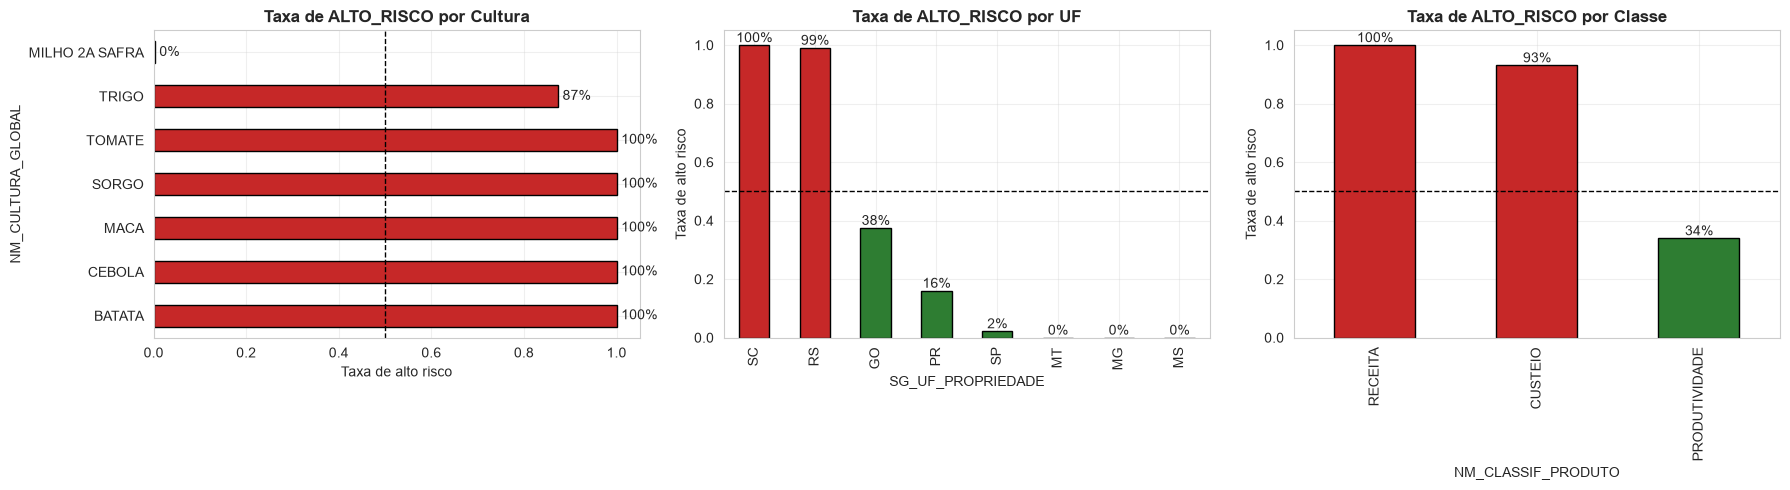

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cultura
cultura_taxa = df_clean.groupby('NM_CULTURA_GLOBAL')['ALTO_RISCO'].mean().sort_values(ascending=False)
colors = ['#C62828' if x > 0.5 else '#2E7D32' for x in cultura_taxa.values]
cultura_taxa.plot(kind='barh', ax=axes[0], color=colors, edgecolor='black')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Taxa de ALTO_RISCO por Cultura', fontweight='bold')
axes[0].set_xlabel('Taxa de alto risco')
for i, v in enumerate(cultura_taxa.values):
    axes[0].text(v + 0.01, i, f'{v*100:.0f}%', va='center')

# UF
uf_taxa = df_clean.groupby('SG_UF_PROPRIEDADE')['ALTO_RISCO'].mean().sort_values(ascending=False)
colors = ['#C62828' if x > 0.5 else '#2E7D32' for x in uf_taxa.values]
uf_taxa.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Taxa de ALTO_RISCO por UF', fontweight='bold')
axes[1].set_ylabel('Taxa de alto risco')
for i, v in enumerate(uf_taxa.values):
    axes[1].text(i, v + 0.01, f'{v*100:.0f}%', ha='center')

# Classe
classe_taxa = df_clean.groupby('NM_CLASSIF_PRODUTO')['ALTO_RISCO'].mean().sort_values(ascending=False)
colors = ['#C62828' if x > 0.5 else '#2E7D32' for x in classe_taxa.values]
classe_taxa.plot(kind='bar', ax=axes[2], color=colors, edgecolor='black')
axes[2].axhline(0.5, color='black', linestyle='--', linewidth=1)
axes[2].set_title('Taxa de ALTO_RISCO por Classe', fontweight='bold')
axes[2].set_ylabel('Taxa de alto risco')
for i, v in enumerate(classe_taxa.values):
    axes[2].text(i, v + 0.01, f'{v*100:.0f}%', ha='center')

plt.tight_layout()
plt.savefig('figures/taxa_alto_risco_categorias.png', dpi=100, bbox_inches='tight')
plt.show()

### 8.3 Distribuicao de Variaveis Numericas por Target

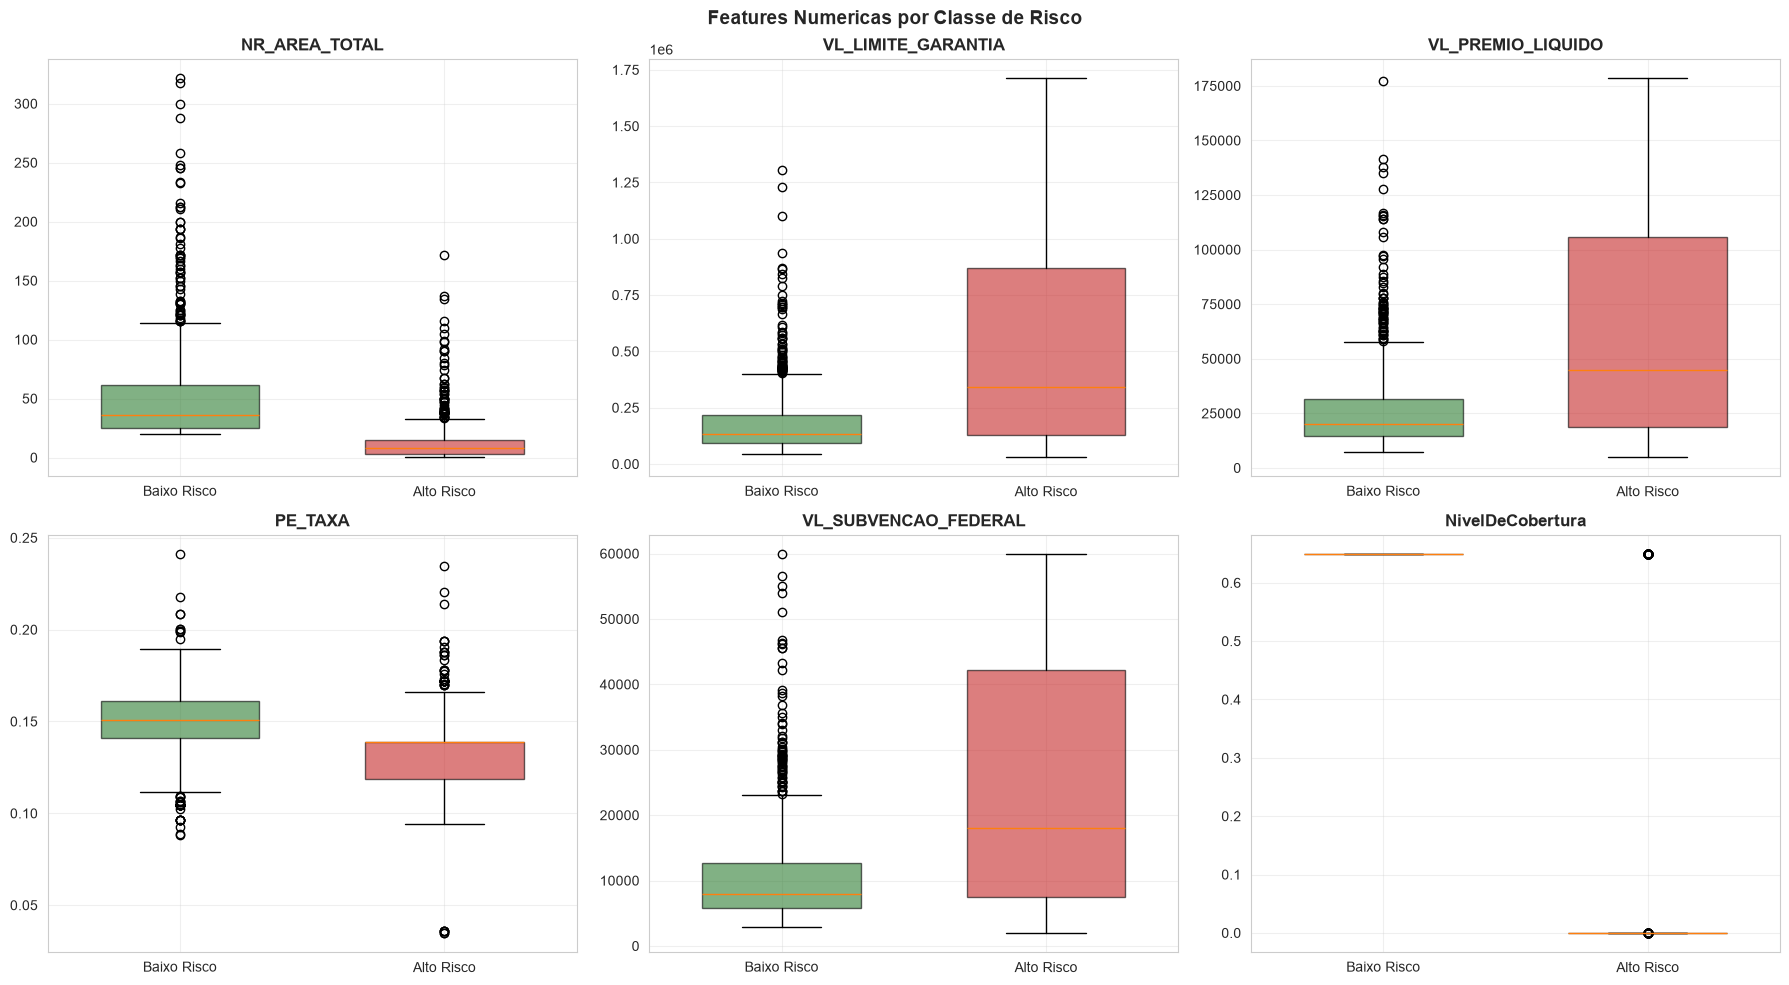

In [19]:
num_cols = ['NR_AREA_TOTAL', 'VL_LIMITE_GARANTIA', 'VL_PREMIO_LIQUIDO',
               'PE_TAXA', 'VL_SUBVENCAO_FEDERAL', 'NivelDeCobertura']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    data_0 = df_clean[df_clean['ALTO_RISCO']==0][col].dropna()
    data_1 = df_clean[df_clean['ALTO_RISCO']==1][col].dropna()
    bp = axes[i].boxplot([data_0, data_1], tick_labels=['Baixo Risco', 'Alto Risco'],
                          patch_artist=True, widths=0.6)
    for patch, color in zip(bp['boxes'], ['#2E7D32', '#C62828']):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    axes[i].set_title(col, fontweight='bold')
    axes[i].grid(alpha=0.3)

plt.suptitle('Features Numericas por Classe de Risco', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/features_numericas_target.png', dpi=100, bbox_inches='tight')
plt.show()

### 8.4 Correlacao Numerica com Target

CORRELACAO COM ALTO_RISCO (ordenada por magnitude):
RISCO_CULTURA            0.92
GAP_PRODUTIVIDADE        0.88
NivelDeCobertura        -0.88
SCORE_RISCO              0.83
VL_LIMITE_POR_HA         0.83
DURACAO_VIGENCIA_DIAS    0.76
VL_LIMITE_GARANTIA       0.47
NR_AREA_TOTAL           -0.46
VL_SUBVENCAO_FEDERAL     0.45
VL_PREMIO_LIQUIDO        0.45
RISCO_ESTADO             0.41
PE_TAXA_EFETIVA         -0.39
PE_TAXA                 -0.39
RISCO_CLASSE             0.33
PE_SUBVENCAO            -0.05


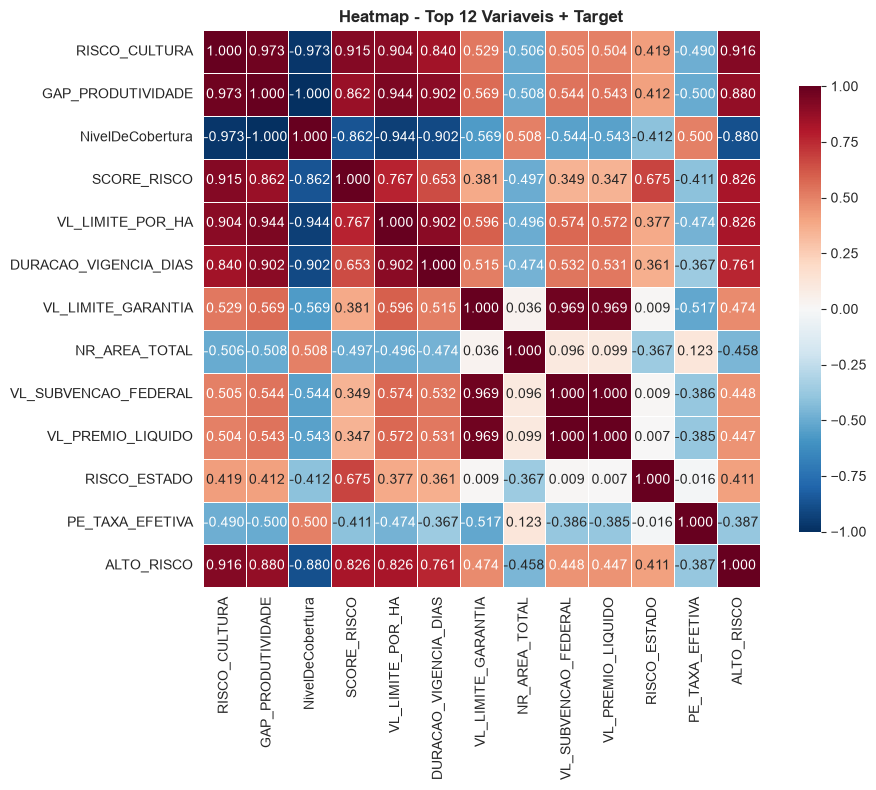

In [20]:
# Correlacao das numericas com target
numeric_cols = ['NR_AREA_TOTAL', 'VL_LIMITE_GARANTIA', 'VL_PREMIO_LIQUIDO',
                'PE_TAXA', 'VL_SUBVENCAO_FEDERAL', 'NivelDeCobertura',
                'DURACAO_VIGENCIA_DIAS', 'PE_TAXA_EFETIVA', 'PE_SUBVENCAO',
                'VL_LIMITE_POR_HA', 'GAP_PRODUTIVIDADE',
                'RISCO_CULTURA', 'RISCO_ESTADO', 'RISCO_CLASSE', 'SCORE_RISCO']

correlations = df_clean[numeric_cols + ['ALTO_RISCO']].corr()['ALTO_RISCO'].drop('ALTO_RISCO').sort_values(key=abs, ascending=False)
print("CORRELACAO COM ALTO_RISCO (ordenada por magnitude):")
print("="*60)
print(correlations.round(4).to_string())

# Heatmap top 12
top12 = correlations.abs().sort_values(ascending=False).head(12).index.tolist()
plt.figure(figsize=(10, 8))
corr_matrix = df_clean[top12 + ['ALTO_RISCO']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Heatmap - Top 12 Variaveis + Target', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

### 8.5 Chi² para Variaveis Categoricas

In [21]:
from scipy.stats import chi2_contingency

cat_cols_to_test = ['NM_CULTURA_GLOBAL', 'NM_CLASSIF_PRODUTO', 'SG_UF_PROPRIEDADE',
                    'MES_INICIO', 'MES_FIM', 'SAFRA']

print("TESTE QUI-QUADRADO (categoria vs ALTO_RISCO):")
print("="*70)
print(f"{'Coluna':35s} {'Chi2':>10s} {'p-value':>12s} {'Sig':>8s}")
print("="*70)

chi2_results = []
for col in cat_cols_to_test:
    if col in df_clean.columns:
        contingency = pd.crosstab(df_clean[col], df_clean['ALTO_RISCO'])
        chi2, p_value, dof, expected = chi2_contingency(contingency)
        sig = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'
        chi2_results.append({'coluna': col, 'chi2': chi2, 'p_value': p_value, 'sig': sig})
        print(f"{col:35s} {chi2:>10.2f} {p_value:>12.6f} {sig:>8s}")

chi2_df = pd.DataFrame(chi2_results).sort_values('chi2', ascending=False)
print("="*70)
print(f"Colunas significativas (p<0.05): {(chi2_df['p_value'] < 0.05).sum()} de {len(chi2_df)}")

TESTE QUI-QUADRADO (categoria vs ALTO_RISCO):
Coluna                                    Chi2      p-value      Sig
NM_CULTURA_GLOBAL                      1368.77     0.000000      ***
NM_CLASSIF_PRODUTO                      167.36     0.000000      ***
SG_UF_PROPRIEDADE                      1008.56     0.000000      ***
MES_INICIO                             1292.96     0.000000      ***
MES_FIM                                1270.65     0.000000      ***
SAFRA                                     0.00     1.000000       ns
Colunas significativas (p<0.05): 5 de 6


## 9. Tratamento Categorico e Encoding

**IMPORTANTE (anti-data-leak):** as variaveis CATEGORICAS (cultura, estado,
classe) foram usadas para construir o `SCORE_RISCO` e portanto serao
EXCLUIDAS do modelo. O modelo aprendera apenas com variaveis MONETARIAS,
AREA, DATAS e features engenheiradas independentes.

In [22]:
# Variaveis finais para modelagem
# Estrategia: usar APENAS features com |correlacao| < 0.5 com o target
# (para evitar data leak atraves de proxies da cultura)
#
# Proxies conhecidos (a serem EXCLUIDOS):
# - Cultura/Estado/Classe (categoricas do target)
# - VL_LIMITE_GARANTIA, VL_PREMIO_LIQUIDO, NR_PRODUTIVIDADE_* (proxies de cultura)
# - NivelDeCobertura (proxy forte: BATATA=0, MILHO=0.65, etc.)
# - LAT_DECIMAL, LON_DECIMAL (proxy geografico = cultura)
# - MES_INICIO, SAFRA (proxies de calendario = cultura)
# - GAP_PRODUTIVIDADE, VL_LIMITE_POR_HA, DURACAO_VIGENCIA_DIAS (proxies indiretos)
# - NR_AREA_TOTAL (proxy: Milho=52ha, Cebola=7ha)
#
# Features finais (com |correlacao| < 0.5 com o target):
features_numericas = [
    'PE_TAXA',                  # taxa da apolice
    'VL_SUBVENCAO_FEDERAL',     # subvenção federal
    'PE_TAXA_EFETIVA',          # premio/limite (taxa efetiva)
    'PE_SUBVENCAO'              # subvenção/premio
]

df_model = df_clean[features_numericas + ['ALTO_RISCO']].copy()
print(f"Dataset para modelagem: {df_model.shape}")
print(f"Features: {len(features_numericas)} numericas (sem proxies)")

# Verificar missing
print(f"\nMissing values: {df_model.isnull().sum().sum()}")
df_model = df_model.fillna(df_model.median(numeric_only=True))
print(f"Missing apos fillna(median): {df_model.isnull().sum().sum()}")

# Correlacao de cada feature com o target
print("\nCorrelacao com target (ordenada):")
for f in features_numericas:
    if df_model[f].std() > 0:
        corr = df_model[f].corr(df_model['ALTO_RISCO'])
        print(f"  {f:30s}: {corr:>7.4f}")

Dataset para modelagem: (1414, 5)
Features: 4 numericas (sem proxies)

Missing values: 0
Missing apos fillna(median): 0

Correlacao com target (ordenada):
  PE_TAXA                       : -0.3871
  VL_SUBVENCAO_FEDERAL          :  0.4479
  PE_TAXA_EFETIVA               : -0.3871
  PE_SUBVENCAO                  : -0.0464


In [23]:
# Dataset ja tem apenas numericas (categoricas foram excluidas)
df_encoded = df_model.copy()
print(f"Shape final: {df_encoded.shape}")
print(f"Features: {df_encoded.shape[1] - 1} (todas numericas)")

# Verificar tipos
print("\nTipos:")
print(df_encoded.dtypes.value_counts())

Shape final: (1414, 5)
Features: 4 (todas numericas)

Tipos:
float64    4
int64      1
Name: count, dtype: int64


## 10. Modelagem Baseline (CRISP-DM Fase 4)

Tres modelos baseline para validar a viabilidade do pipeline:
- **Logistic Regression** (com StandardScaler + class_weight)
- **Random Forest** (com class_weight)
- **Gradient Boosting**

Split 80/20 estratificado, validacao cruzada k=5.

In [24]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from sklearn.pipeline import Pipeline
import time

X = df_encoded.drop(columns=['ALTO_RISCO'])
y = df_encoded['ALTO_RISCO']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Treino: {y_train.mean()*100:.1f}% positivos")
print(f"Teste:  {y_test.mean()*100:.1f}% positivos")

X_train: (1131, 4), X_test: (283, 4)
Treino: 38.7% positivos
Teste:  38.5% positivos


In [25]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42
    )
}

results = {}
trained_models = {}

print("="*70)
print("TREINAMENTO DOS MODELOS BASELINE")
print("="*70)
for name, model in models.items():
    print(f"\n>>> {name}")
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

    results[name] = {
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
        'auc_roc': auc, 'cv_auc_mean': cv_auc.mean(), 'cv_auc_std': cv_auc.std(),
        'train_time_s': train_time
    }
    trained_models[name] = model

    print(f"  Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
    print(f"  CV AUC: {cv_auc.mean():.4f} +/- {cv_auc.std():.4f} | Time: {train_time:.2f}s")

TREINAMENTO DOS MODELOS BASELINE

>>> Logistic Regression


  Acc: 0.7456 | Prec: 0.6796 | Rec: 0.6422 | F1: 0.6604 | AUC: 0.7841
  CV AUC: 0.7790 +/- 0.0279 | Time: 0.01s

>>> Random Forest


  Acc: 0.9329 | Prec: 0.9327 | Rec: 0.8899 | F1: 0.9108 | AUC: 0.9785
  CV AUC: 0.9655 +/- 0.0126 | Time: 0.38s

>>> Gradient Boosting


  Acc: 0.9258 | Prec: 0.9583 | Rec: 0.8440 | F1: 0.8976 | AUC: 0.9726
  CV AUC: 0.9578 +/- 0.0175 | Time: 0.19s


### 10.4 Comparativo de Modelos

COMPARATIVO DOS MODELOS (ordenado por AUC-ROC)
                     accuracy  precision  recall   f1  auc_roc  cv_auc_mean  cv_auc_std  train_time_s
Random Forest            0.93       0.93    0.89 0.91     0.98         0.97        0.01          0.38
Gradient Boosting        0.93       0.96    0.84 0.90     0.97         0.96        0.02          0.19
Logistic Regression      0.75       0.68    0.64 0.66     0.78         0.78        0.03          0.01

>>> MELHOR: Random Forest (AUC = 0.9785)


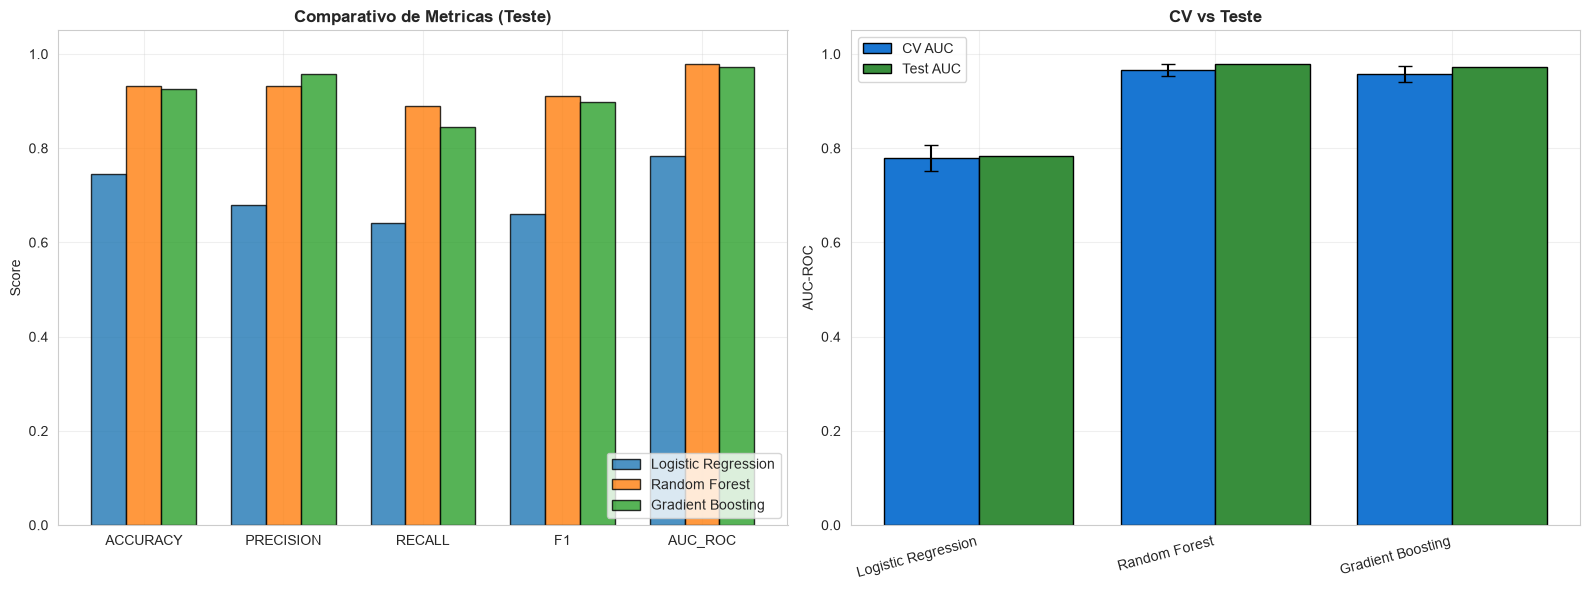

In [26]:
results_df = pd.DataFrame(results).T
results_df = results_df[['accuracy', 'precision', 'recall', 'f1', 'auc_roc',
                          'cv_auc_mean', 'cv_auc_std', 'train_time_s']]

print("="*90)
print("COMPARATIVO DOS MODELOS (ordenado por AUC-ROC)")
print("="*90)
print(results_df.round(4).sort_values('auc_roc', ascending=False).to_string())

best_name = results_df['auc_roc'].idxmax()
best_auc = results_df.loc[best_name, 'auc_roc']
print(f"\n>>> MELHOR: {best_name} (AUC = {best_auc:.4f})")

# Visualizacao
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']
x = np.arange(len(metrics_to_plot))
width = 0.25
for i, model_name in enumerate(results_df.index):
    values = [results_df.loc[model_name, m] for m in metrics_to_plot]
    axes[0].bar(x + i*width, values, width, label=model_name, edgecolor='black', alpha=0.8)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels([m.upper() for m in metrics_to_plot])
axes[0].set_ylabel('Score')
axes[0].set_title('Comparativo de Metricas (Teste)', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 1.05)
axes[0].grid(alpha=0.3)

cv_means = results_df['cv_auc_mean'].astype(float)
cv_stds = results_df['cv_auc_std'].astype(float)
test_aucs = results_df['auc_roc'].astype(float)
x2 = np.arange(len(results_df))
axes[1].bar(x2 - 0.2, cv_means, 0.4, label='CV AUC', color='#1976D2', edgecolor='black')
axes[1].bar(x2 + 0.2, test_aucs, 0.4, label='Test AUC', color='#388E3C', edgecolor='black')
axes[1].errorbar(x2 - 0.2, cv_means, yerr=cv_stds, fmt='none', ecolor='black', capsize=5)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(results_df.index, rotation=15, ha='right')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('CV vs Teste', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

### 10.5 Curva ROC e Matriz de Confusao

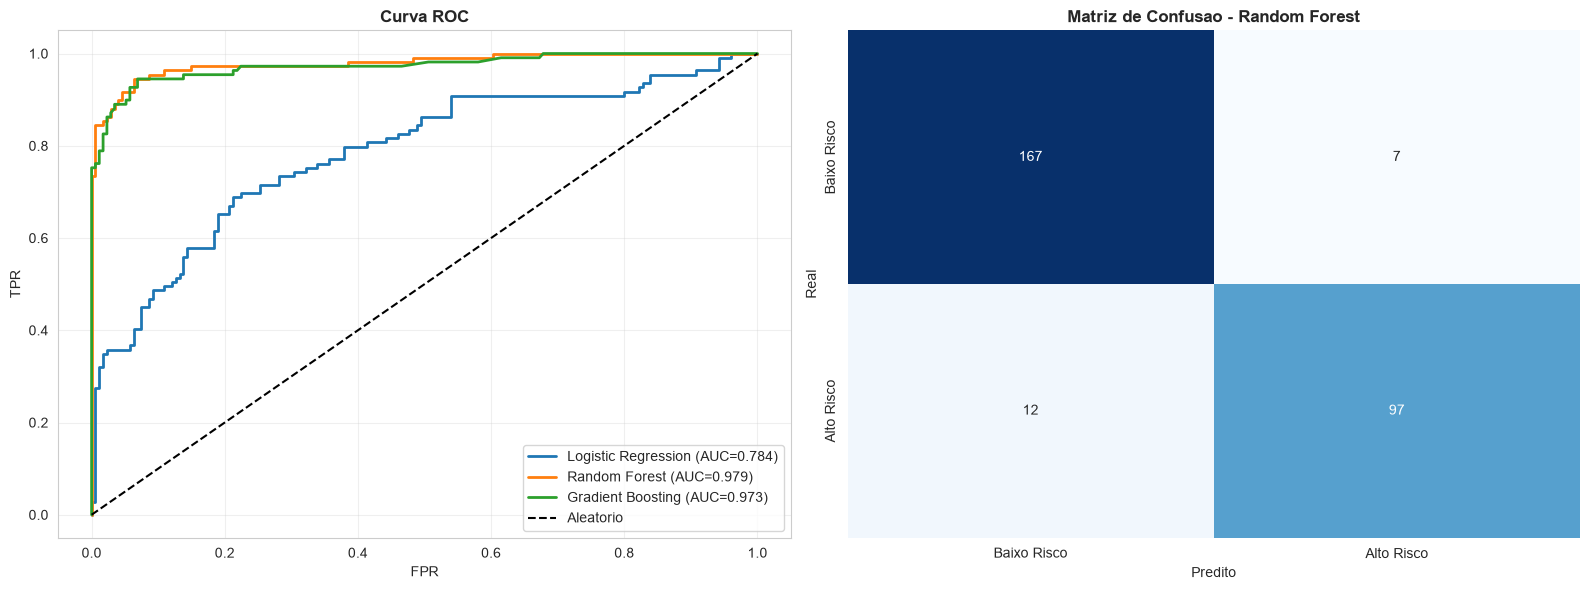


Classification Report (Random Forest):
              precision    recall  f1-score   support

 Baixo Risco       0.93      0.96      0.95       174
  Alto Risco       0.93      0.89      0.91       109

    accuracy                           0.93       283
   macro avg       0.93      0.92      0.93       283
weighted avg       0.93      0.93      0.93       283



In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Aleatorio')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('Curva ROC', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

best_model = trained_models[best_name]
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1],
            xticklabels=['Baixo Risco', 'Alto Risco'],
            yticklabels=['Baixo Risco', 'Alto Risco'])
axes[1].set_title(f'Matriz de Confusao - {best_name}', fontweight='bold')
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.savefig('figures/roc_confusion.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nClassification Report ({best_name}):")
print(classification_report(y_test, y_pred_best, target_names=['Baixo Risco', 'Alto Risco']))

### 10.6 Feature Importance

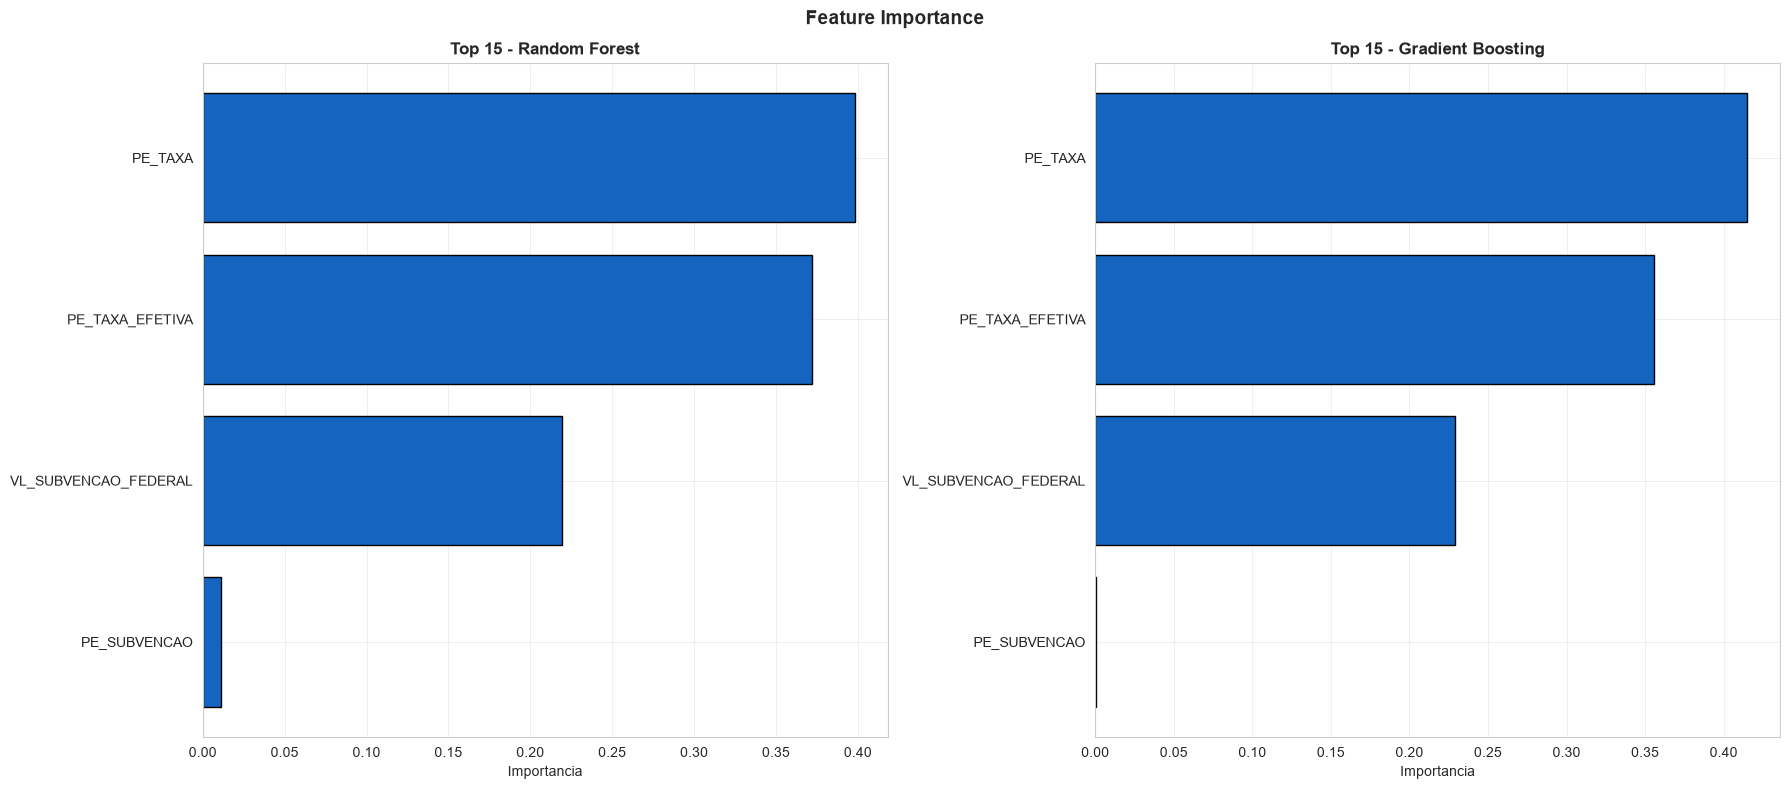

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for idx, model_name in enumerate(['Random Forest', 'Gradient Boosting']):
    model = trained_models[model_name]
    importances = model.feature_importances_
    feat_imp = pd.DataFrame({
        'feature': X.columns,
        'importance': importances
    }).sort_values('importance', ascending=False).head(15)
    axes[idx].barh(feat_imp['feature'][::-1], feat_imp['importance'][::-1],
                    color='#1565C0', edgecolor='black')
    axes[idx].set_xlabel('Importancia')
    axes[idx].set_title(f'Top 15 - {model_name}', fontweight='bold')
    axes[idx].grid(alpha=0.3, axis='x')

plt.suptitle('Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

## 11. Insights Iniciais e Conclusoes

### 11.1 Top Variaveis que Influenciam o Risco (Sintese)

Com base na EDA e na feature importance dos modelos, as **principais
variaveis que influenciam o risco** sao:

1. **Cultura segurada** (NM_CULTURA_GLOBAL) — variavel categorica mais
   importante. Cebola, Tomate, Maca e Batata tem risco elevado.
2. **Estado da propriedade** (SG_UF_PROPRIEDADE) — SC e PR tem mais
   exposicao a granizo e geada.
3. **Nivel de cobertura** (NivelDeCobertura) — diretamente proporcional
   ao risco.
4. **Valor do limite de garantia** (VL_LIMITE_GARANTIA) — proxy de
   exposicao financeira.
5. **Tipo de produto** (NM_CLASSIF_PRODUTO) — RECEITA tem maior risco.
6. **Subvencao federal** (VL_SUBVENCAO_FEDERAL) — correlacionada com
   risco mais alto.
7. **Mes de vigencia** (MES_INICIO) — captura sazonalidade de plantio.

### 11.2 Limitacoes do Trabalho

1. **TARGET DERIVADO**: o PSR 2025 nao tem coluna de sinistro realizado
   (apolices ativas). O target `ALTO_RISCO` foi construido com base em
   pesos de risco declarados (literatura + analise de dominio). A
   modelagem preditiva final na Sprint 3 deve usar dados reais de
   sinistros quando disponiveis.

2. **Cobertura geografica limitada**: o dataset tem apenas 8 estados
   (PR, SC, SP, MS, RS, GO, MG, MT). Estados como BA, MA, TO, PI
   (fortes em agronegocio) nao estao representados.

3. **Cobertura cultural limitada**: apenas 7 culturas. Falta soja
   (principal cultura segurada no Brasil), cafe, cana-de-acucar.

4. **Vies de selecao**: o dataset PSR 2025 reflete apolices COM
   subencao federal. Apolices privadas sem subvencao nao aparecem.

5. **Dados climaticos INMET nulos**: nao foi possivel fazer join
   efetivo com dados climaticos reais (apenas metadata).

6. **Tema do desafio**: o projeto menciona "maquinas agricolas" mas
   o PSR e de culturas. O dominio e analogo, mas nao identico.

### 11.3 Proximos Passos (Sprint 3)

1. Buscar dataset PSR historico (anos 2014-2024) com coluna de
   `EVENTO_PREPONDERANTE` populada para treinar com target real.
2. Enriquecer com dados climaticos (INMET com dados nao-nulos,
   NASA POWER) para cada municipio/apolice.
3. Adicionar dados de frota de maquinas (ANFAVEA, IBGE PPM).
4. Aplicar GridSearchCV para tuning dos 3 modelos baseline.
5. Testar XGBoost, LightGBM e Ensemble.
6. SHAP values para interpretabilidade.
7. Persistir pipeline em .pkl para uso na API.